# How effectively do different optimizers find high-quality biological sequences?
In the following notebook three different optimizon apporaches are evaluated with the MLP surrogate to answer the question how well are they doing if the surrgate suffers from distributional shift. 


In [8]:
import os
from experiment_runner import ExperimentRunner
import pandas as pd
from assets.plot import plot_trajectory_quality_vs_distance, plot_surrogate_reliability_vs_distance
from assets.plot import plot_trajectory_optimization_progress
import matplotlib.pyplot as plt

## Naive Appraoch: Single Mutant Walker and a MLP surrogate

#### TFBind8 

In [2]:
if not os.path.exists('results/trajectory_smw_tfbind8.csv'):
    runner = ExperimentRunner(keyword='smw_tfbind8')
    df = runner.run_and_save()
else: 
    df = pd.read_csv('results/trajectory_smw_tfbind8.csv')

In [3]:
# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
print(f"Mean max oracle score: {mean_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f}")

Mean max oracle score: 0.8253
Mean median oracle score: 0.7069


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

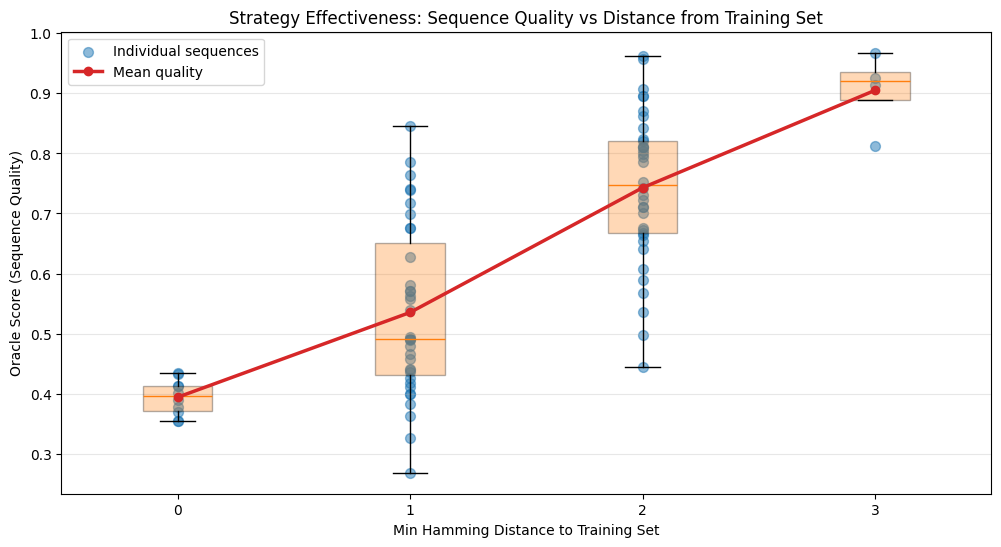

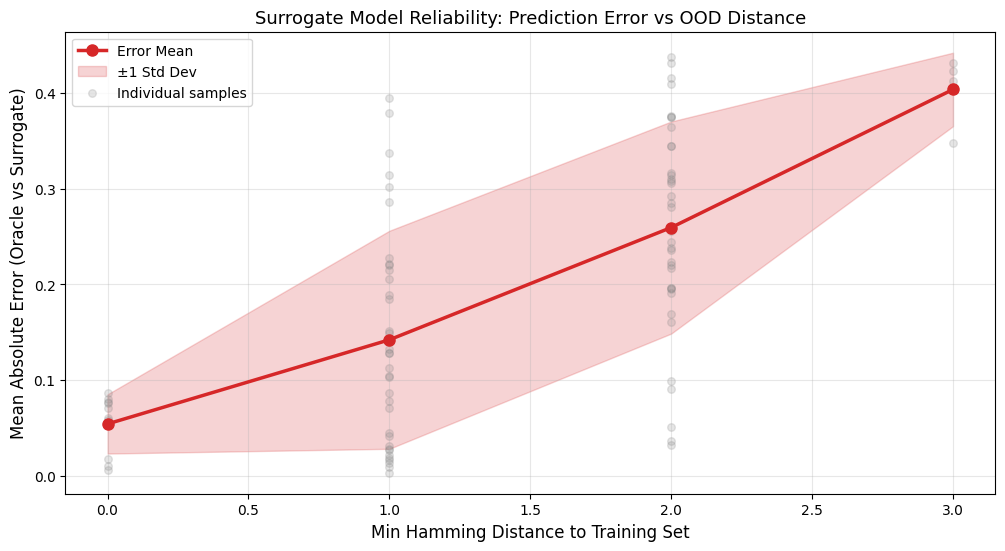

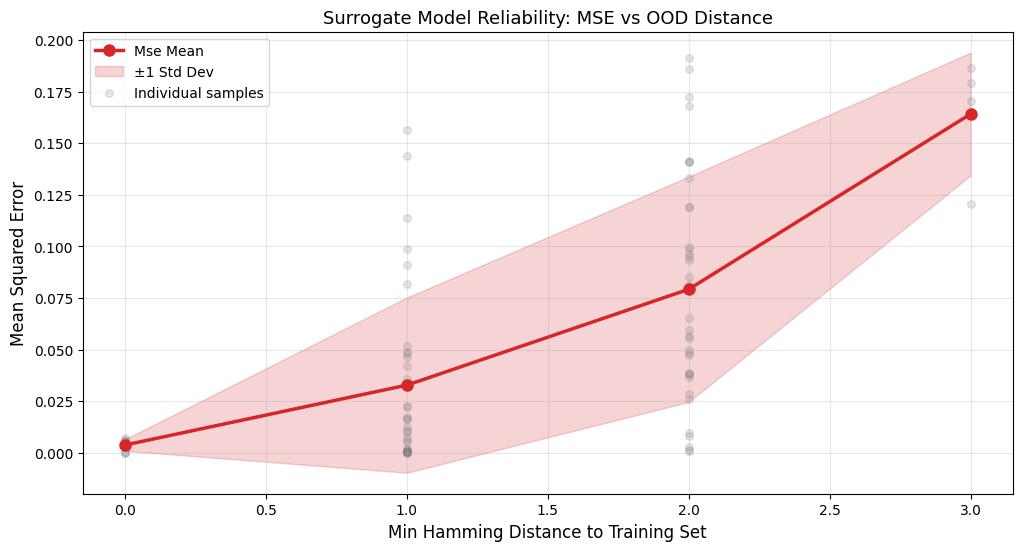

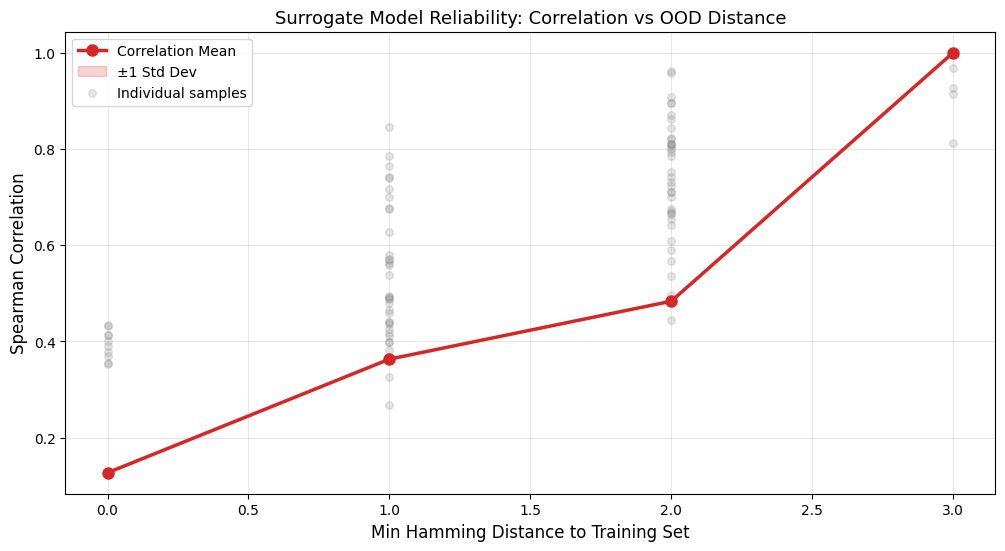

In [4]:
plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')

#### GB1

In [5]:
if not os.path.exists('results/trajectory_smw_gb1.csv'):
    experiment_runner = ExperimentRunner(keyword = 'smw_gb1')
    df = experiment_runner.run_and_save(parallel=False)
else:
    df = pd.read_csv('results/trajectory_smw_gb1.csv')


############################################################
Running experiment: smw_gb1
Method: smw
Dataset: gb1
Runs: 10
Iterations per run: 15
Parallel: False
############################################################


Run 1/10 - SMW
Selected 27657 training samples.
Training score range: -10.896890414973896 - -2.7896733393825137
✓ Run 1: 24 records

Run 2/10 - SMW
Selected 27657 training samples.
Training score range: -10.896890414973896 - -2.7896733393825137
✓ Run 2: 28 records

Run 3/10 - SMW
Selected 27657 training samples.
Training score range: -10.896890414973896 - -2.7896733393825137
✓ Run 3: 24 records

Run 4/10 - SMW
Selected 27657 training samples.
Training score range: -10.896890414973896 - -2.7896733393825137
✓ Run 4: 33 records

Run 5/10 - SMW
Selected 27657 training samples.
Training score range: -10.896890414973896 - -2.7896733393825137
✓ Run 5: 28 records

Run 6/10 - SMW
Selected 27657 training samples.
Training score range: -10.896890414973896 - -2.78967333938251

In [6]:
# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")


Mean max oracle score: 1.1974 +- 1.3242
Mean median oracle score: -0.2618 +- 2.6051


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

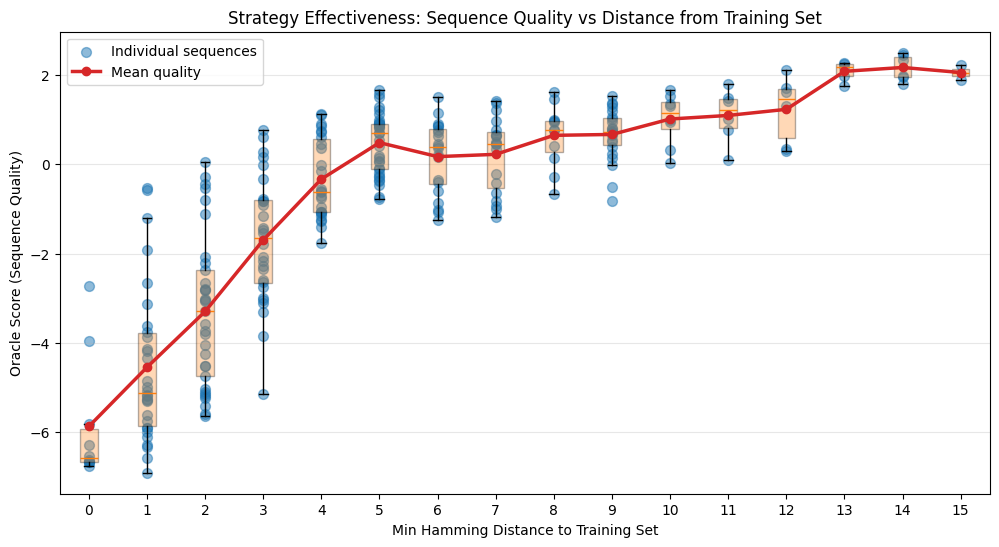

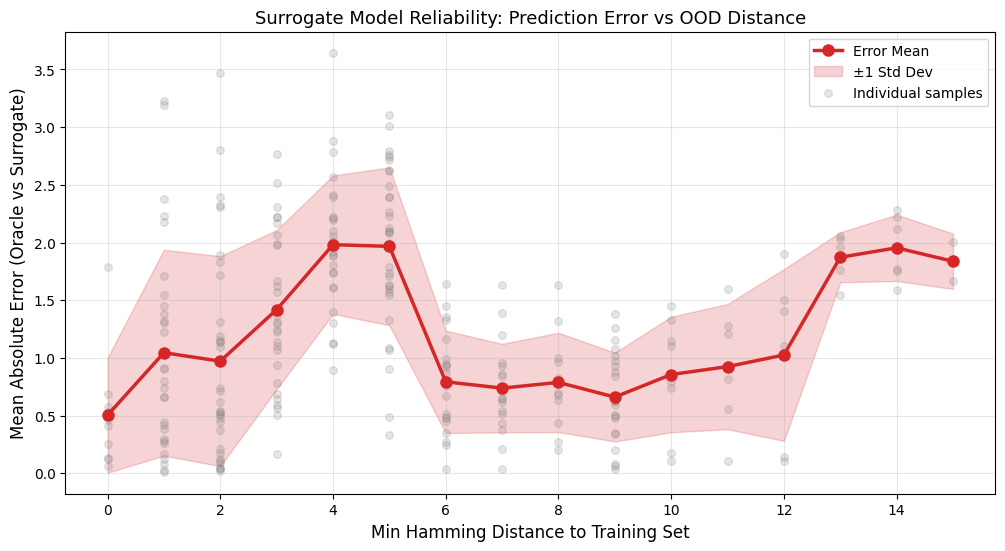

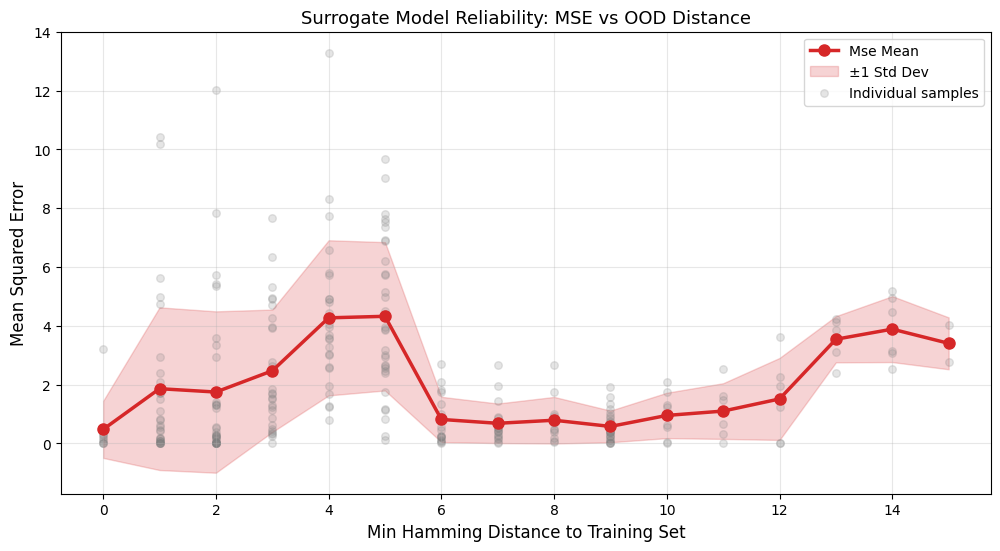

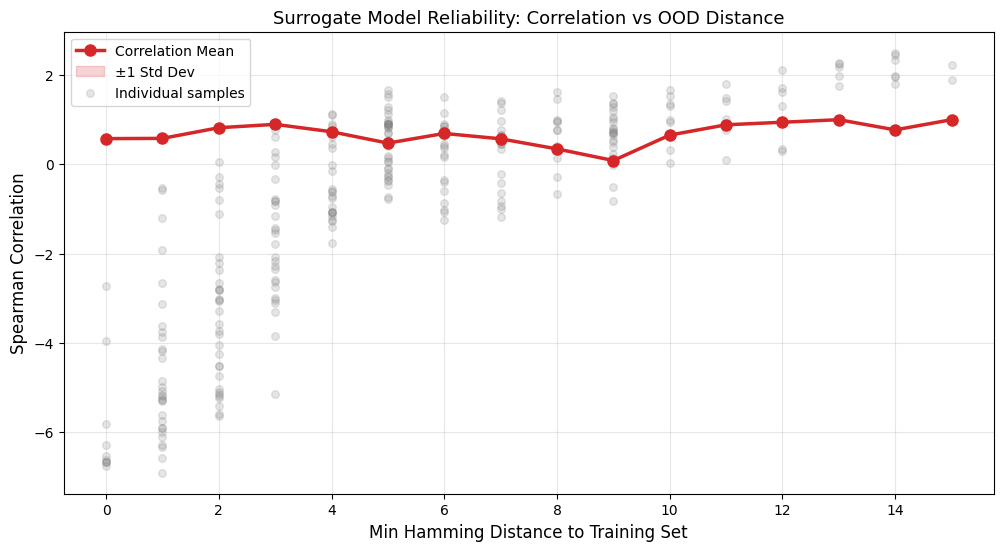

In [7]:
plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')

## Reinforcement Appraoch
Scince the naive SMW appraoch is very limited in exploration as the experiments above show, in the following a Reinforcement Learning Approach is used for the same two problems.

In this appraoch the sequences are predicted by a LSTM and scored with a RF. The best 20% of the predicted sequences are then mixed with sequences from the training set and used to retrain the LSTM. 

#### TFBind8

In [8]:
if not os.path.exists('results/trajectory_rl_tfbind8.csv'):
    experiment_runner = ExperimentRunner(keyword='rl_tfbind8')
    df = experiment_runner.run_and_save(parallel=False)
else:
    df = pd.read_csv('results/trajectory_rl_tfbind8.csv')


############################################################
Running experiment: rl_tfbind8
Method: rl
Dataset: tfbind8
Runs: 10
Iterations per run: 15
Parallel: False
############################################################


Run 1/10 - RL
Selected 4105 training samples.
Training score range: 0.0019585206173360348 - 0.439296156167984
Pretraining epoch 0/30, Loss: 1.3246
Pretraining epoch 5/30, Loss: 1.1953
Pretraining epoch 10/30, Loss: 1.1543
Pretraining epoch 15/30, Loss: 1.1311
Pretraining epoch 20/30, Loss: 1.1130
Pretraining epoch 25/30, Loss: 1.0971
RL Iteration 1/15 (temp=0.50)
Pretraining epoch 0/20, Loss: 1.3984
Pretraining epoch 5/20, Loss: 0.9593
Pretraining epoch 10/20, Loss: 0.8420
Pretraining epoch 15/20, Loss: 0.7319
RL Iteration 2/15 (temp=0.54)
Pretraining epoch 0/20, Loss: 0.9719
Pretraining epoch 5/20, Loss: 0.6203
Pretraining epoch 10/20, Loss: 0.4725
Pretraining epoch 15/20, Loss: 0.3864
RL Iteration 3/15 (temp=0.57)
Pretraining epoch 0/20, Loss: 1.0747
Pretr

In [9]:
# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")


Mean max oracle score: 0.9493 +- 0.0252
Mean median oracle score: 0.7724 +- 0.0901


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

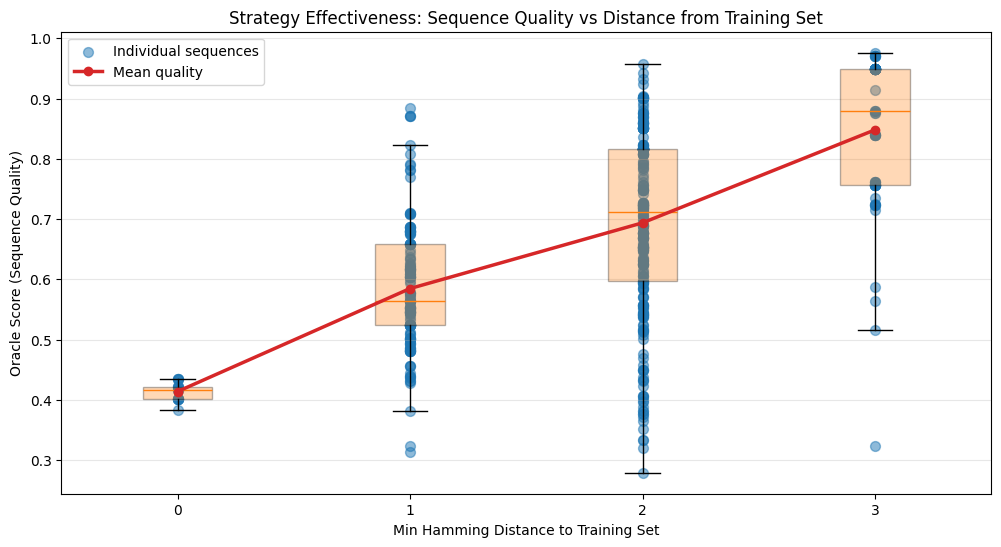

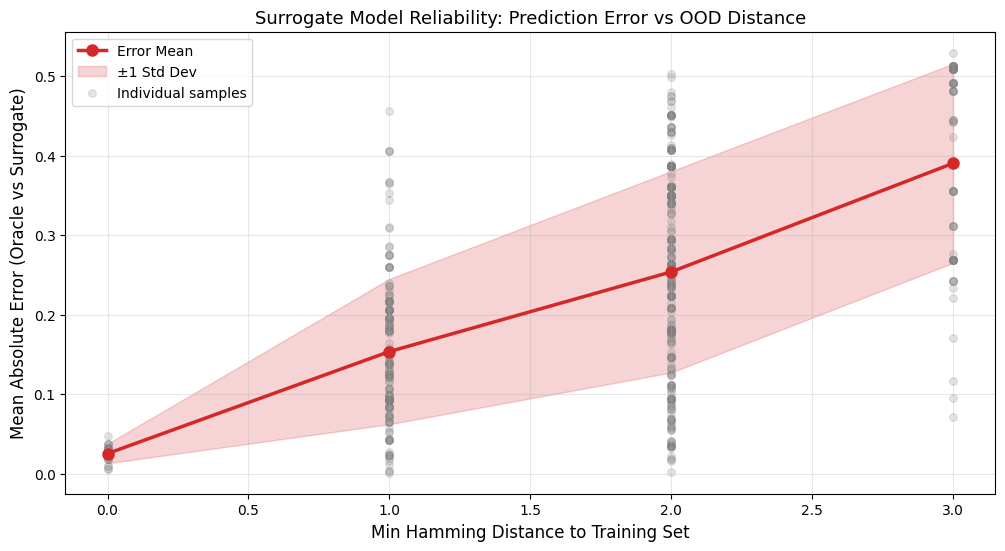

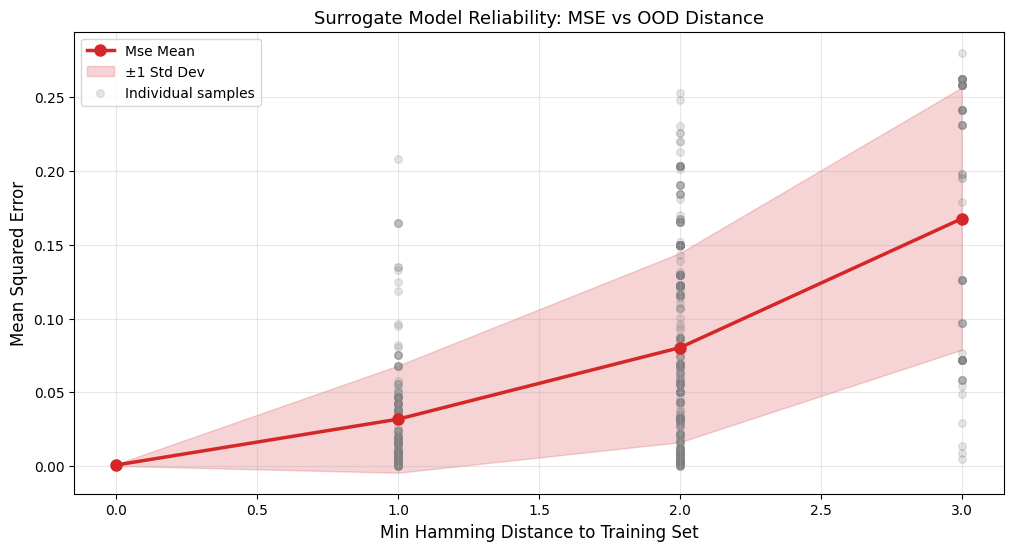

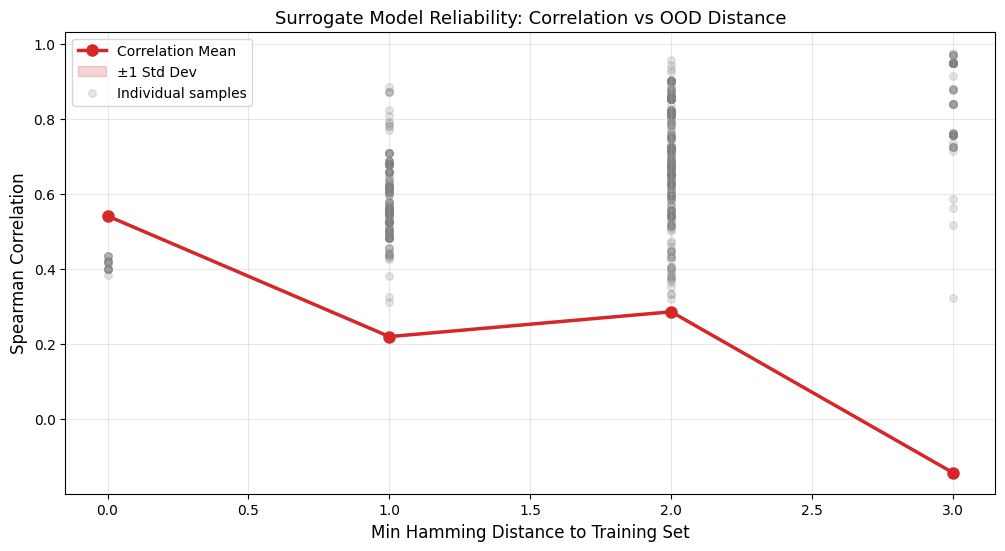

In [10]:
plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')

The optimization progress is only plotted for one single run

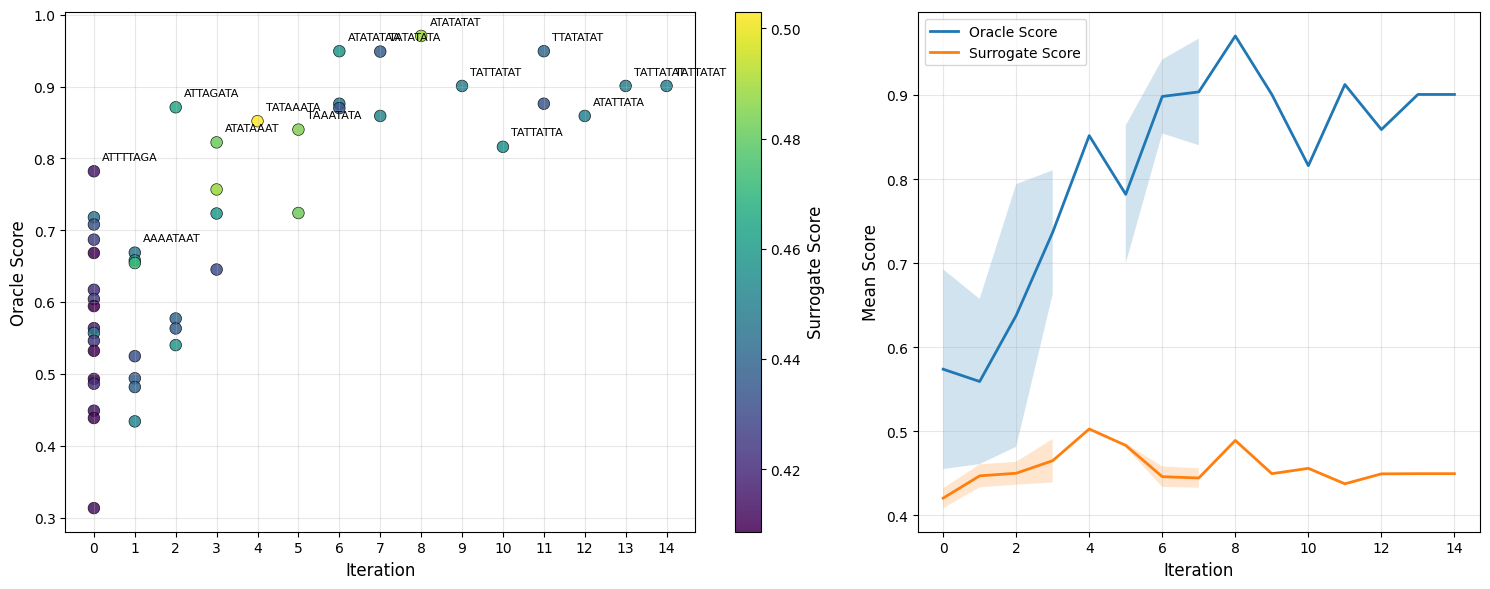

In [11]:
# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=1)
plt.show()

#### GB1

In [12]:
if os.path.exists('results/trajectory_rl_gb1.csv'):
    df = pd.read_csv('results/trajectory_rl_gb1.csv')
else:
    experiment_runner = ExperimentRunner(keyword='rl_gb1')
    df = experiment_runner.run_and_save(parallel=False)


############################################################
Running experiment: rl_gb1
Method: rl
Dataset: gb1
Runs: 10
Iterations per run: 15
Parallel: False
############################################################


Run 1/10 - RL
Selected 27657 training samples.
Training score range: -10.896890414973896 - -2.7896733393825137
Pretraining epoch 0/30, Loss: 0.4052
Pretraining epoch 5/30, Loss: 0.1880
Pretraining epoch 10/30, Loss: 0.1798
Pretraining epoch 15/30, Loss: 0.1762
Pretraining epoch 20/30, Loss: 0.1731
Pretraining epoch 25/30, Loss: 0.1714
RL Iteration 1/15 (temp=0.50)
Pretraining epoch 0/20, Loss: 0.5361
Pretraining epoch 5/20, Loss: 0.3599
Pretraining epoch 10/20, Loss: 0.3149
Pretraining epoch 15/20, Loss: 0.2629
RL Iteration 2/15 (temp=0.54)
Pretraining epoch 0/20, Loss: 3.3975
Pretraining epoch 5/20, Loss: 2.7233
Pretraining epoch 10/20, Loss: 2.0898
Pretraining epoch 15/20, Loss: 1.9509
RL Iteration 3/15 (temp=0.57)
Pretraining epoch 0/20, Loss: 3.6700
Pretraining 

Mean max oracle score: 4.7548 +- 2.1042
Mean median oracle score: -0.5558 +- 0.4300


/Users/meier/Documents/MasterThesis/assets/plot.py:418: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(subset[oracle_col], subset[surrogate_col]).correlation


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

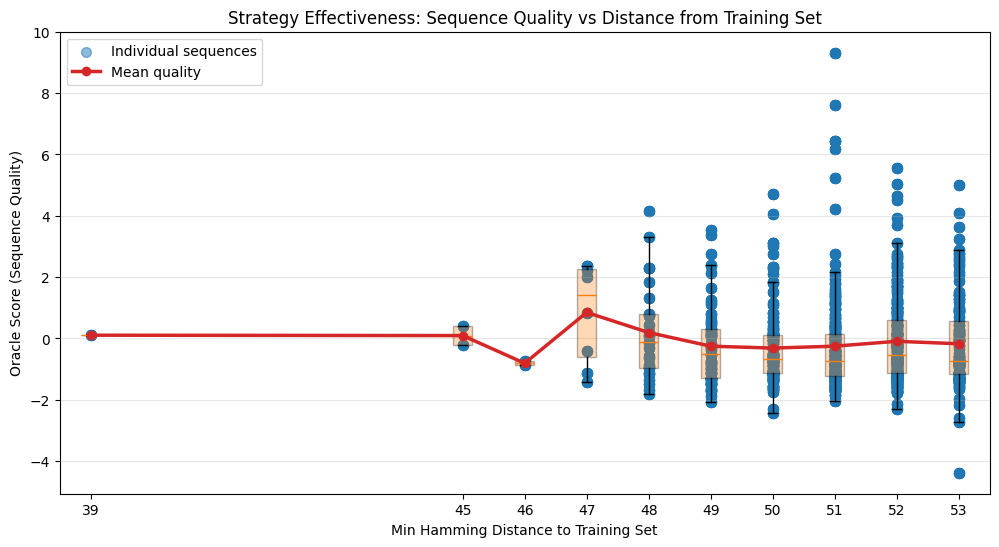

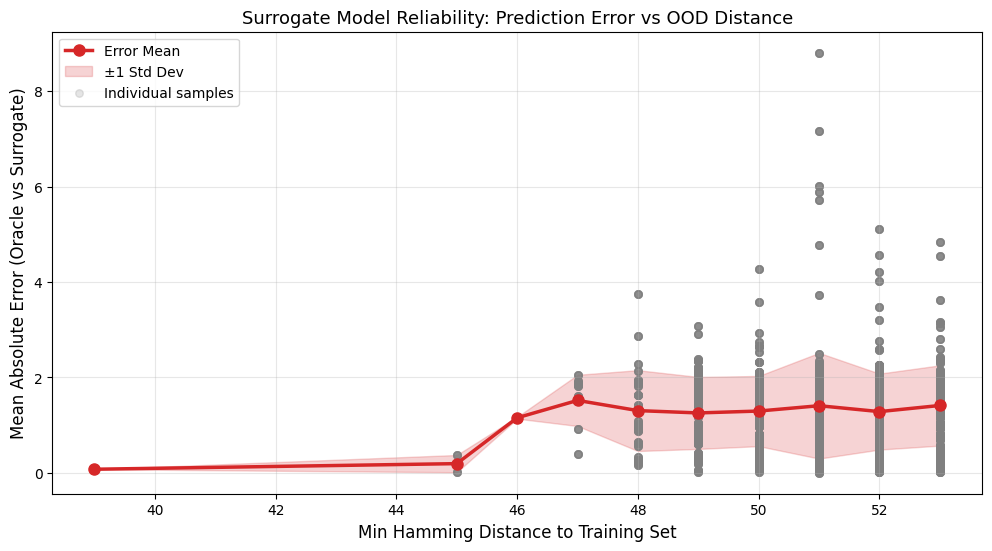

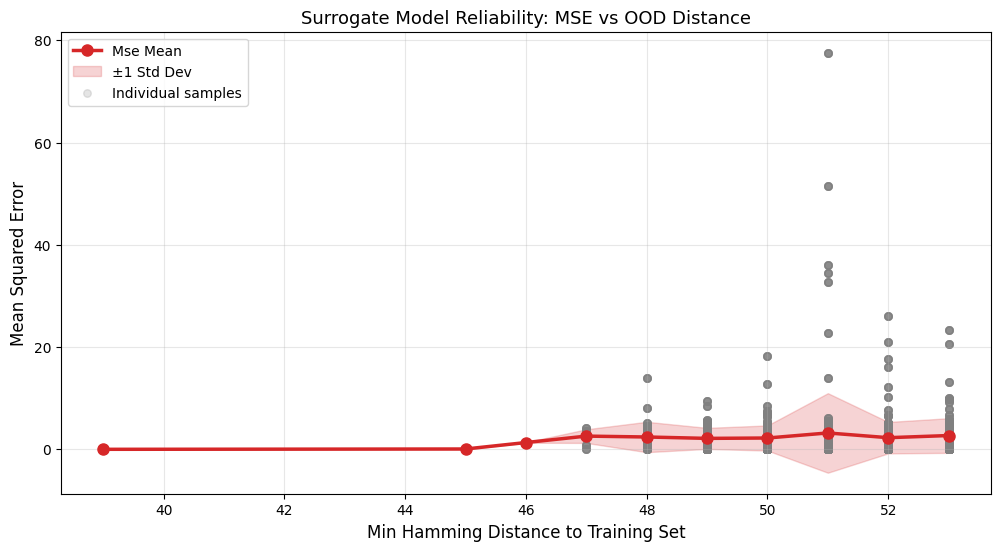

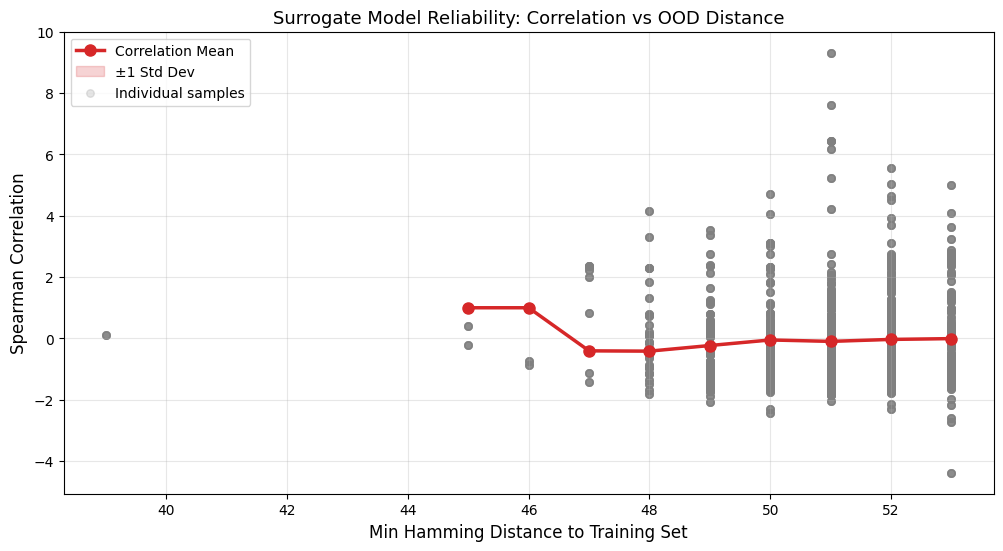

In [13]:
# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")

plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')


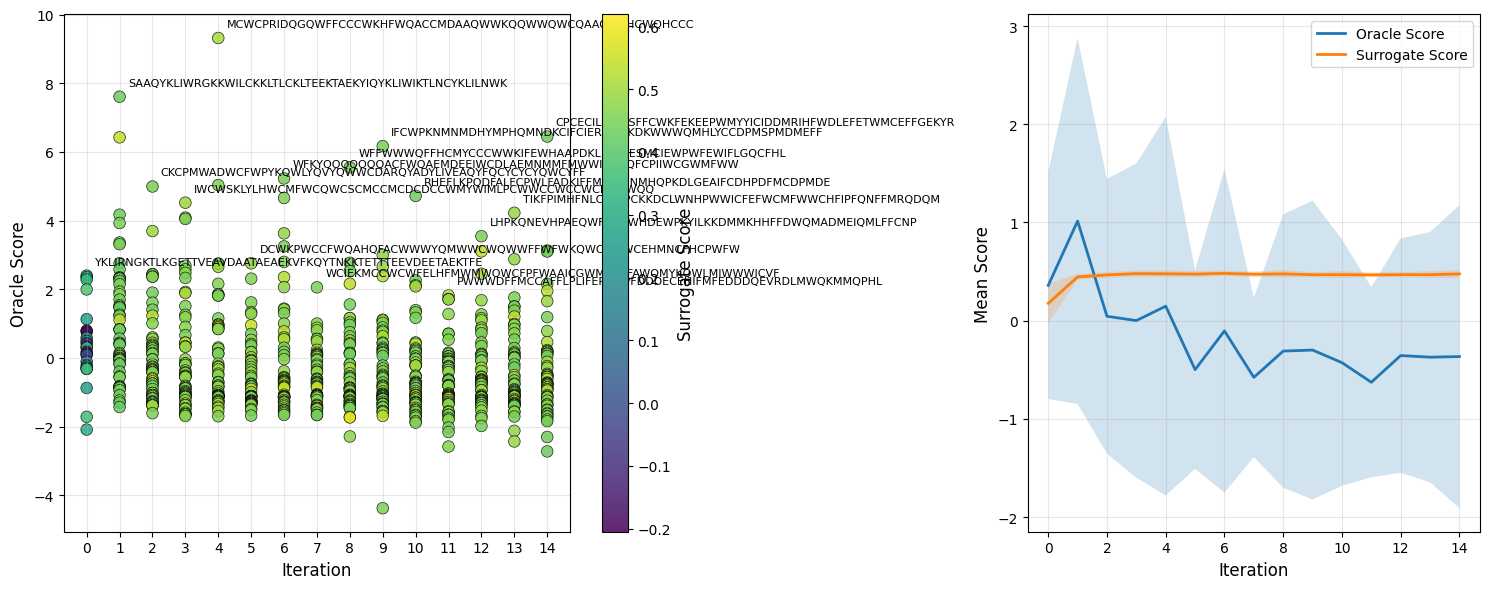

In [14]:
# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=1)
plt.show()

## GFlow Net Experiments

In [2]:
if not os.path.exists('results/trajectory_gfn_tfbind8.csv'):
    runner = ExperimentRunner(keyword='gfn_tfbind8')
    df = runner.run_and_save(parallel=False)
else:
    df = pd.read_csv('results/trajectory_gfn_tfbind8.csv')


############################################################
Running experiment: gfn_tfbind8
Method: gfn
Dataset: tfbind8
Runs: 1
Iterations per run: 15
Parallel: False
############################################################


Run 1/1 - GFN
Selected 4105 training samples.
Training score range: 0.0019585206173360348 - 0.439296156167984

GFlowNet Iteration 1/15
  Dataset size: 4105
  Fitting surrogate...
  Training GFlowNet (5000 steps)...
Step 500/5000, TB Loss: 47.5315, LogZ: 0.4845
Step 1000/5000, TB Loss: 47.4887, LogZ: 0.9447
Step 1500/5000, TB Loss: 42.0194, LogZ: 1.3865
Step 2000/5000, TB Loss: 33.9990, LogZ: 1.8100
Step 2500/5000, TB Loss: 28.7290, LogZ: 2.2173
Step 3000/5000, TB Loss: 28.3255, LogZ: 2.6161
Step 3500/5000, TB Loss: 25.0950, LogZ: 3.0005
Step 4000/5000, TB Loss: 23.9403, LogZ: 3.3659
Step 4500/5000, TB Loss: 23.7098, LogZ: 3.7143
Step 5000/5000, TB Loss: 26.9486, LogZ: 4.0358
  Generating candidates (batch_size=64)...
  Oracle scores — max: 0.9293, mean: 0.4

Mean max oracle score: 0.8803 +- 0.0553
Mean median oracle score: 0.4393 +- 0.0158


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

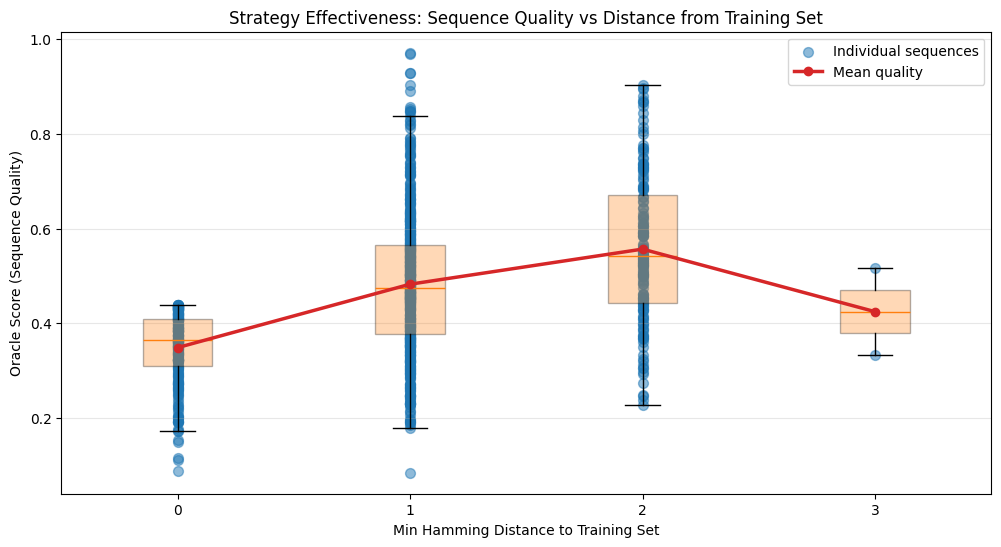

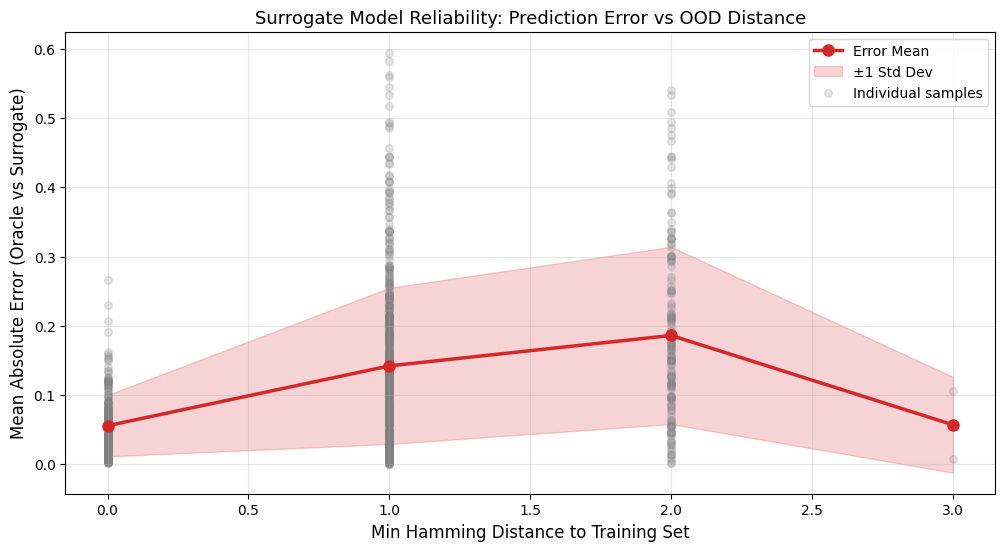

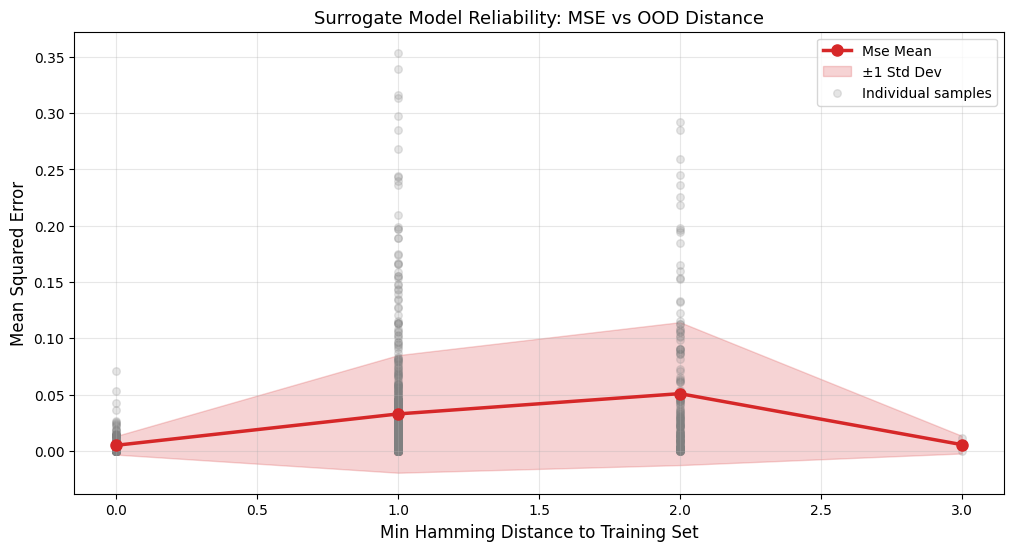

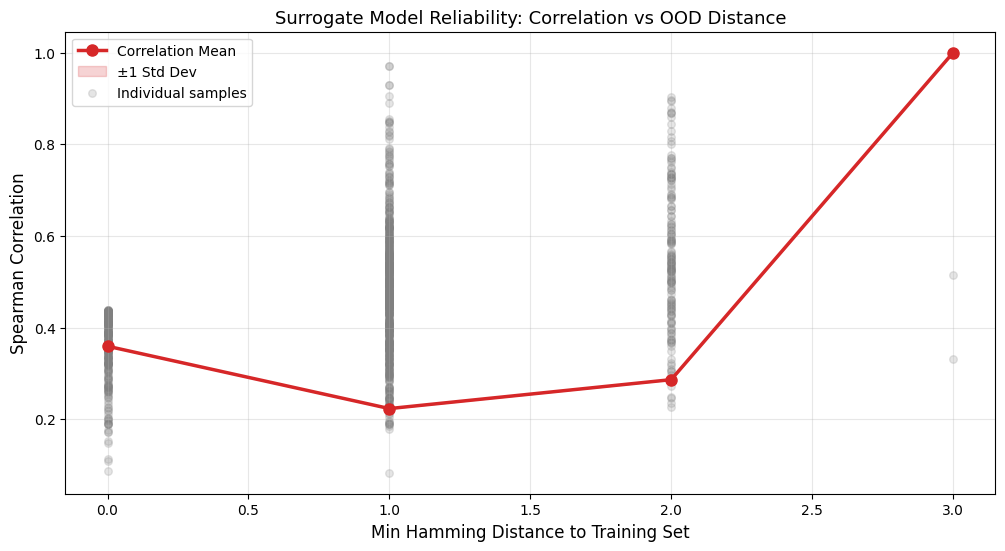

In [3]:
# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")

plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')



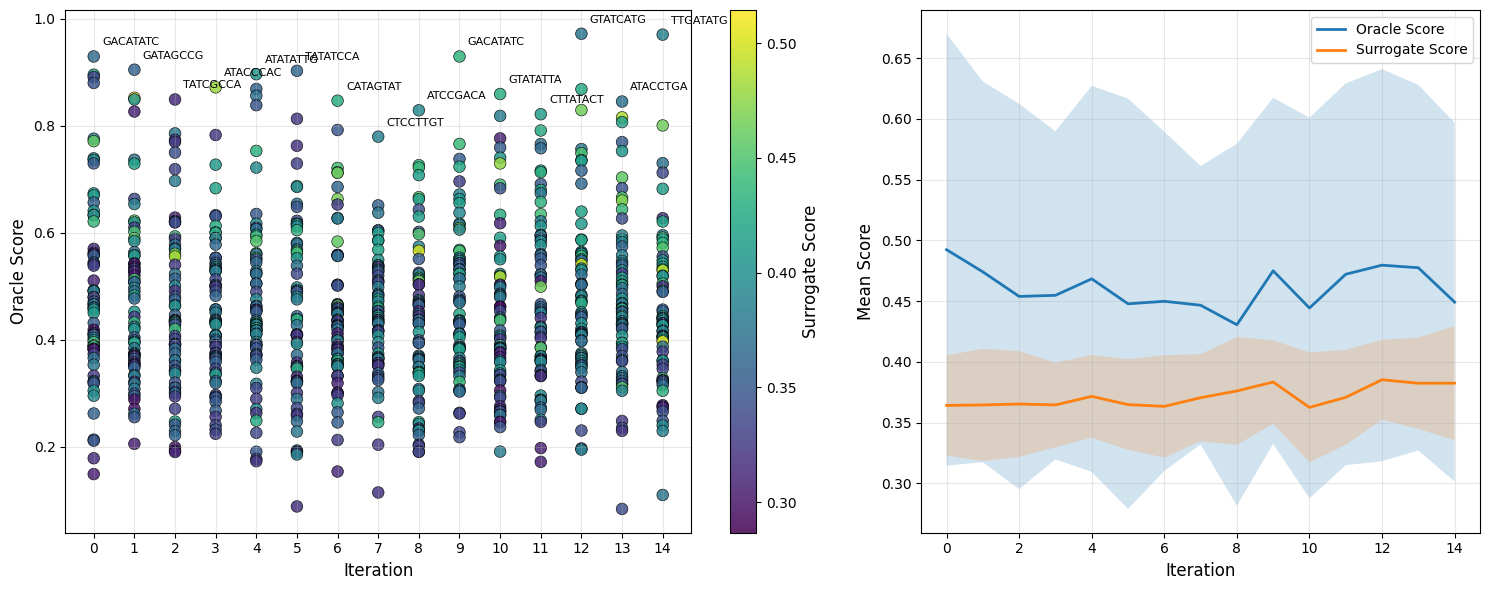

In [4]:
# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=1)
plt.show()

#### GB1

In [19]:
if not os.path.exists('results/trajectory_gfn_gb1.csv'):
    runner = ExperimentRunner(keyword='gfn_gb1')
    df = runner.run_and_save(parallel=False)
else:
    df = pd.read_csv('results/trajectory_gfn_gb1.csv')

Summary:
13522.8s	744	  Runs: 1
13522.8s	745	  Iterations per run: 14.0
13522.8s	746	  Avg records per run: 3840.0
13522.8s	747	
13522.8s	748	Oracle scores:
13522.8s	749	  Min: -3.3838
13522.8s	750	  Max: 8.2092
13522.8s	751	  Mean: 0.5051
13522.8s	752	
13522.8s	753	Hamming distances:
13522.8s	754	  Min: 33
13522.8s	755	  Max: 53.0
13522.8s	756	  Mean: 49.5
13522.8s	757	Total time: 13429.3 seconds (223.8 minutes)
13528.5s	758	Experiment finished.

Mean max oracle score: 6.6332 +- 0.9940
Mean median oracle score: 0.3059 +- 0.0919


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

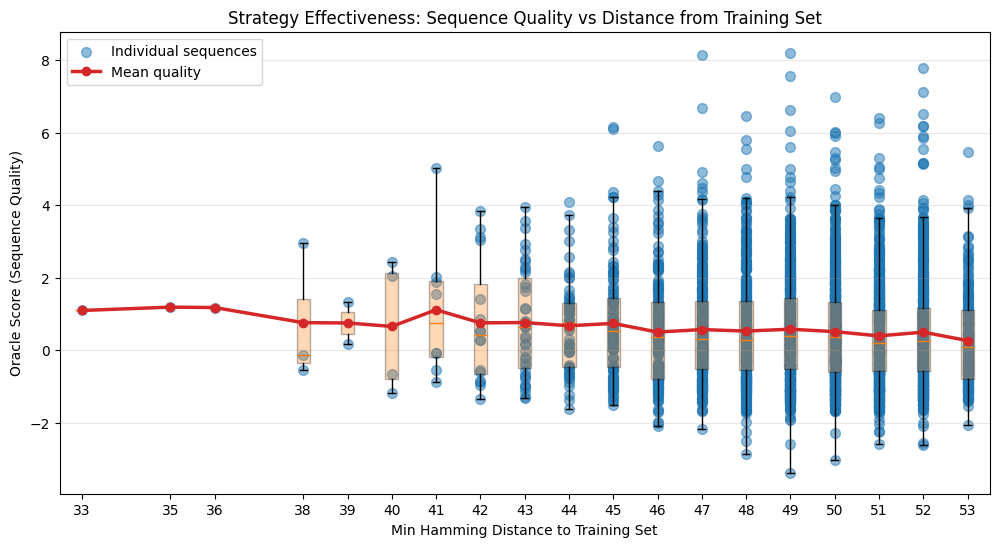

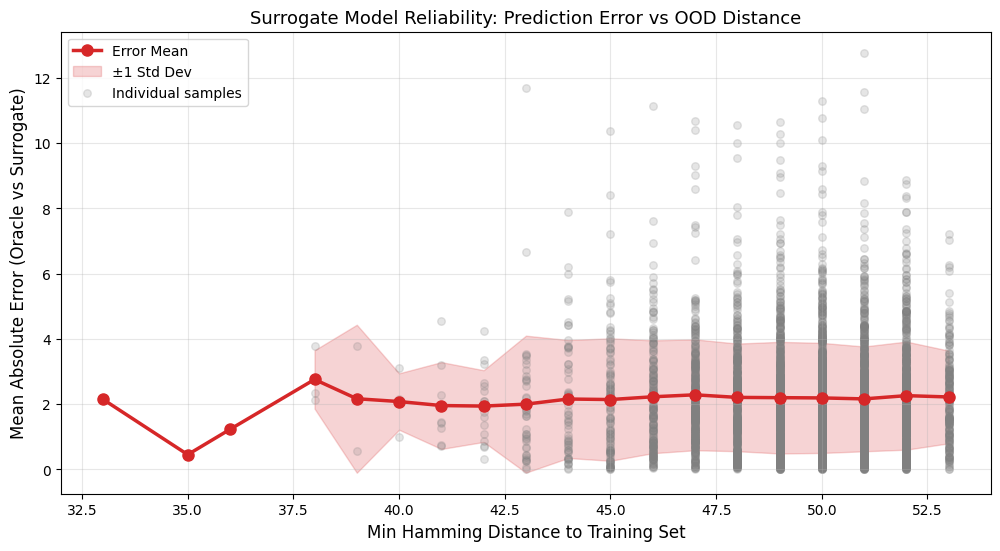

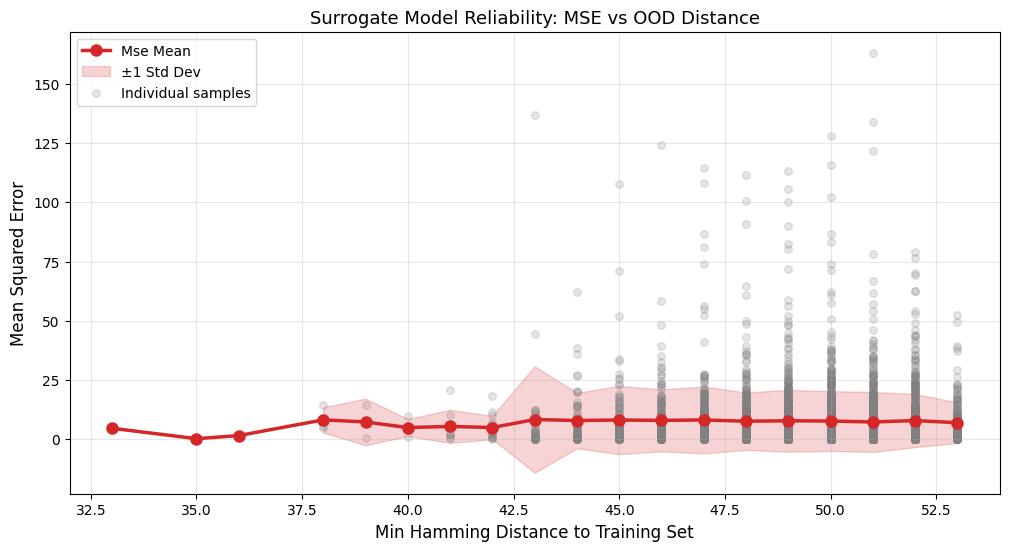

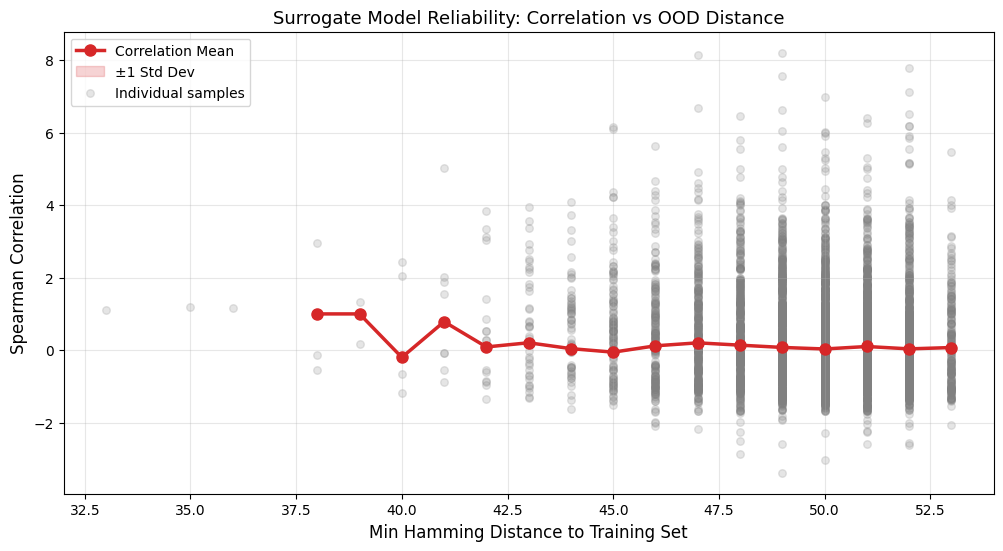

In [20]:
# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")

plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')

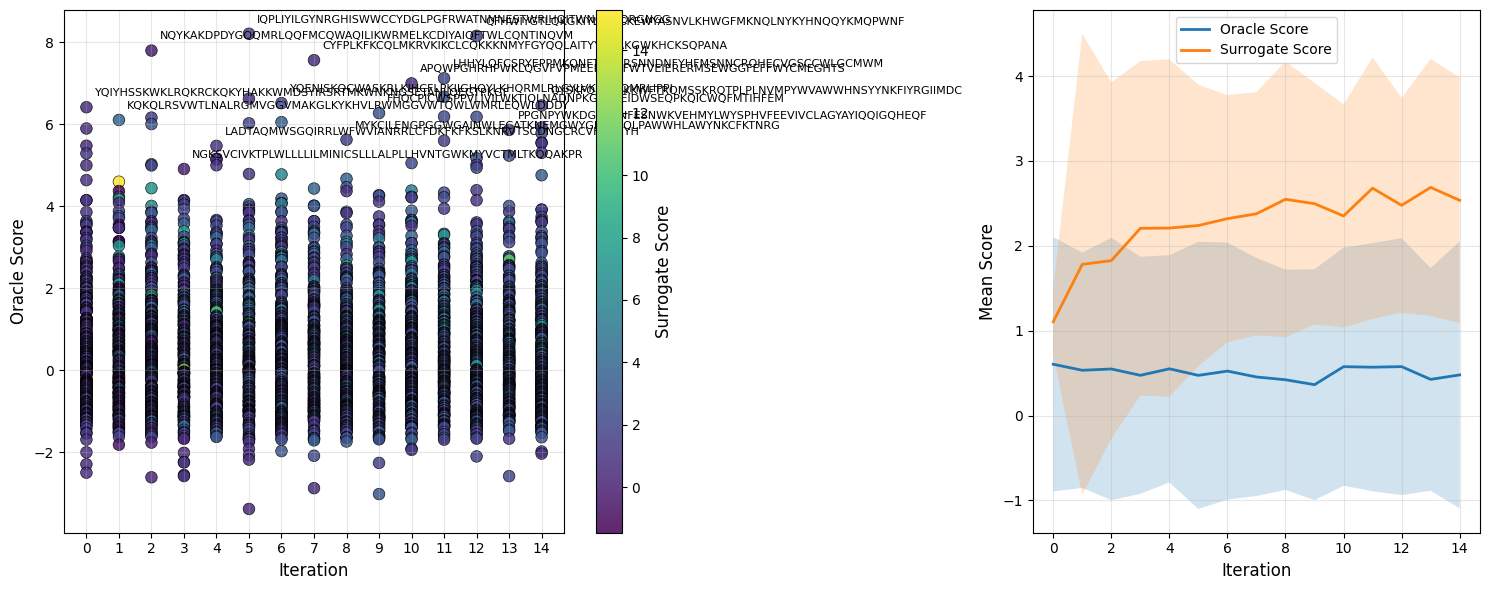

In [21]:
# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=1)
plt.show()

## Comparison of all the models

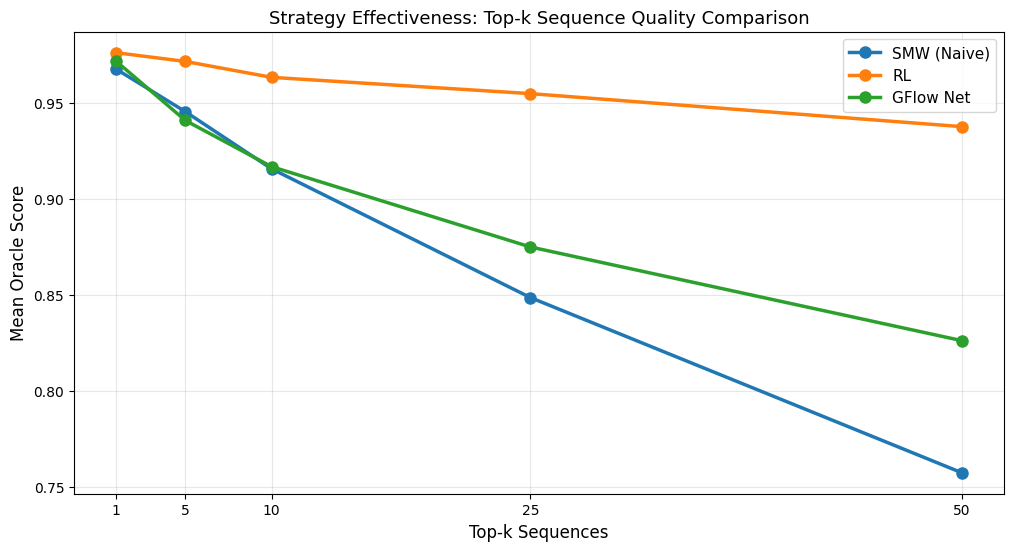

In [18]:
from assets.plot import plot_strategy_comparison_topk
import pandas as pd

# Load trajectory data from each strategy
df_smw = pd.read_csv('results/trajectory_smw_tfbind8.csv')
df_rl = pd.read_csv('results/trajectory_rl_tfbind8.csv')
df_gfn = pd.read_csv('results/trajectory_gfn_tfbind8.csv')

# Compare strategies
plot_strategy_comparison_topk({
    'SMW (Naive)': df_smw,
    'RL': df_rl,
    'GFlow Net': df_gfn
})

plt.show()

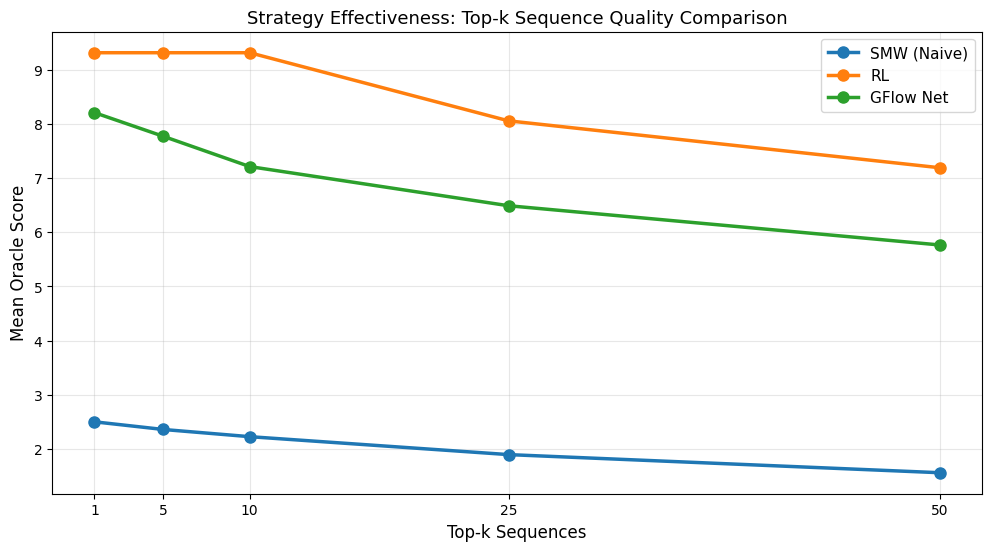

In [17]:
# Load trajectory data from each strategy
df_smw = pd.read_csv('results/trajectory_smw_gb1.csv')
df_rl = pd.read_csv('results/trajectory_rl_gb1.csv')
df_gfn = pd.read_csv('results/trajectory_gfn_gb1.csv')

# Compare strategies
plot_strategy_comparison_topk({
    'SMW (Naive)': df_smw,
    'RL': df_rl,
    'GFlow Net': df_gfn
})

plt.show()

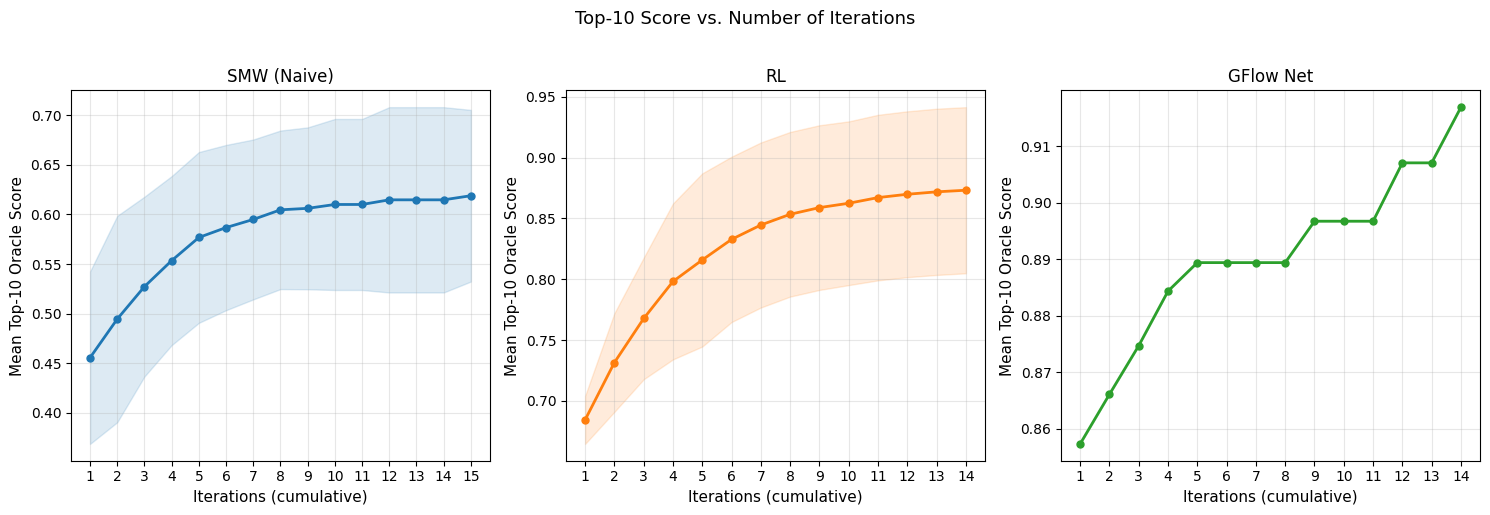

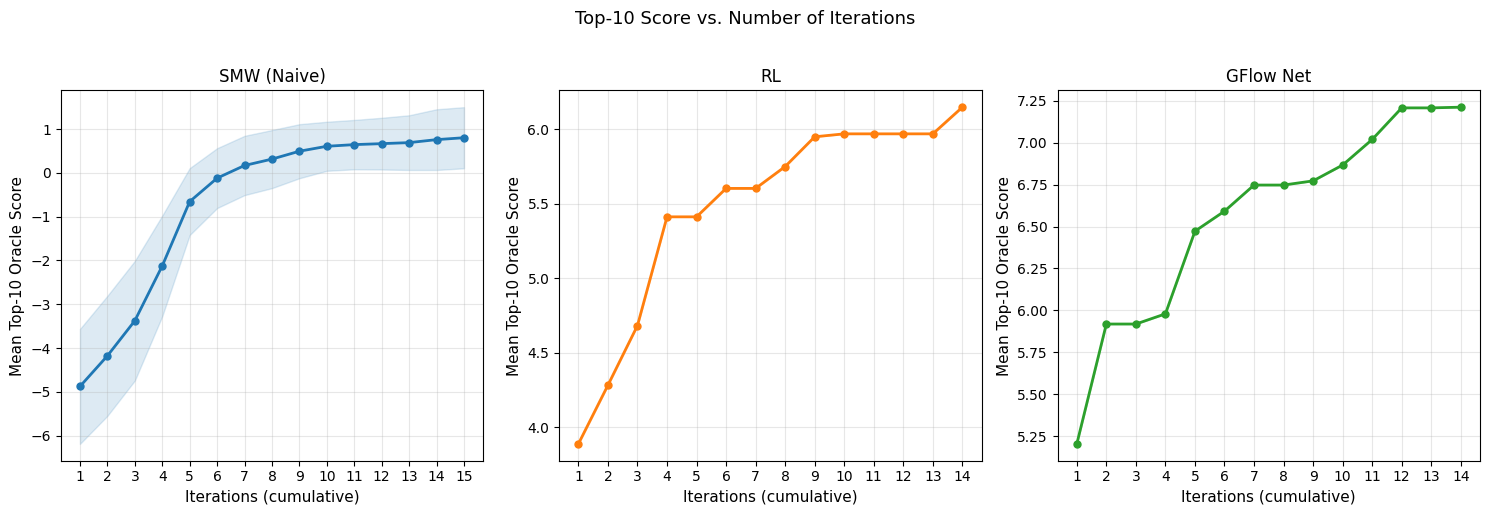

In [15]:
from assets.plot import plot_topk_over_iterations

df_smw = pd.read_csv('results/trajectory_smw_tfbind8.csv')
df_rl  = pd.read_csv('results/trajectory_rl_tfbind8.csv')
df_gfn = pd.read_csv('results/trajectory_gfn_tfbind8.csv')

plot_topk_over_iterations(
    {'SMW (Naive)': df_smw, 'RL': df_rl, 'GFlow Net': df_gfn},
    k=10
)
plt.show()

df_smw = pd.read_csv('results/trajectory_smw_gb1.csv')
df_rl  = pd.read_csv('results/trajectory_rl_gb1.csv')
df_gfn = pd.read_csv('results/trajectory_gfn_gb1.csv')
plot_topk_over_iterations(
    {'SMW (Naive)': df_smw, 'RL': df_rl, 'GFlow Net': df_gfn},
    k=10
)
plt.show()

##### Missing std shadows:
1. RL at GB1 (lower, middle):
The stds are non-zero (~0.07 max), so the band is being computed correctly. The issue is that it's invisible at the RL scale: RL scores range ~4–6.3, and a ±0.07 band is too thin to see compared to the SMW band (which spans ~±1 on a -6 to +1 scale).
2. GFlow Net approaches:
As GFlowNet runs quite a while, just one test was run so far. 

In [16]:
# print score ranges of dataframe
print(f"SMW (Naive) score range: {df_smw['oracle_score'].min():.4f} - {df_smw['oracle_score'].max():.4f}")
print(f"RL score range: {df_rl['oracle_score'].min():.4f} - {df_rl['oracle_score'].max():.4f}")
print(f"GFlow Net score range: {df_gfn['oracle_score'].min():.4f} - {df_gfn['oracle_score'].max():.4f}")

SMW (Naive) score range: -6.9057 - 2.4994
RL score range: -4.3788 - 9.3154
GFlow Net score range: -3.3838 - 8.2092
